# Week 01 Supply Chain EDA

This notebook explores the Nairobi supply chain dataset for stockout patterns, supplier reliability, regional availability, and data quality.

## Phase 1: Environment Setup

Load the analysis libraries, configure chart styling, and read the CSV dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "Supply-Chain-Dataset.csv"
RISK_COLOR = "#E63946"
POSITIVE_COLOR = "#00C851"
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
df = pd.read_csv(r"D:\ubuntu-analytiq\week01-nairobi-supply-chain.csv")
                 
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())
display(df.dtypes.to_frame("dtype"))

Shape: 4,500 rows x 12 columns


,TransactionID,Date,Product_Name,Category,Supplier,Units_Ordered,Units_Received,Units_Sold,Stock_On_Hand,Lead_Time_Days,Stockout_Flag,Region
0,SCL00001,04/05/2024,Bread 400g,Bakery,Bidco Africa,138,122,30,139,14,No,Ngong Road
1,SCL00002,27/01/2024,Chicken 1kg,Meat,Twiga Foods,255,249,41,223,8,No,Westlands
2,SCL00003,20/02/2023,Sugar 2kg,Grocery,Bidco Africa,363,362,313,114,4,No,Eastleigh
3,SCL00004,13/07/2023,Eggs Tray 30,Eggs,Twiga Foods,63,60,55,105,14,No,Kiambu
4,SCL00005,16/06/2024,Pampers Size 4,Baby,Export Trading Group,65,56,33,92,8,No,Karen


,dtype
TransactionID,str
Date,str
Product_Name,str
Category,str
Supplier,str
Units_Ordered,int64
Units_Received,int64
Units_Sold,int64
Stock_On_Hand,int64
Lead_Time_Days,int64


In [3]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfWeek"] = df["Date"].dt.day_name()

display(df[["Date", "Year", "Month", "Quarter", "DayOfWeek"]].head())
print(df["Date"].dtype)

,Date,Year,Month,Quarter,DayOfWeek
0,2024-05-04,2024,5,2,Saturday
1,2024-01-27,2024,1,1,Saturday
2,2023-02-20,2023,2,1,Monday
3,2023-07-13,2023,7,3,Thursday
4,2024-06-16,2024,6,2,Sunday


datetime64[us]


## Phase 2: Data Quality Assessment

Before doing business analysis, confirm missing values, duplicate IDs, logical consistency, and a quality score.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing Count", ascending=False)

display(quality_report)

,Missing Count,Missing %
TransactionID,0,0.0
Date,0,0.0
Product_Name,0,0.0
Category,0,0.0
Supplier,0,0.0
Units_Ordered,0,0.0
Units_Received,0,0.0
Units_Sold,0,0.0
Stock_On_Hand,0,0.0
Lead_Time_Days,0,0.0


In [5]:
anomalies = df[df["Units_Received"] > df["Units_Ordered"]]
duplicate_count = df.duplicated("TransactionID").sum()
invalid_dates = df["Date"].isna().sum()

print(f"Rows where Units_Received > Units_Ordered: {len(anomalies)}")
print(f"Duplicate TransactionIDs: {duplicate_count}")
print(f"Invalid parsed dates: {invalid_dates}")

Rows where Units_Received > Units_Ordered: 0
Duplicate TransactionIDs: 0
Invalid parsed dates: 0


In [6]:
total_issues = missing.sum() + len(anomalies) + duplicate_count
total_cells = df.shape[0] * df.shape[1]
quality_score = (1 - total_issues / total_cells) * 100

print(f"Data Quality Score: {quality_score:.1f}%")

Data Quality Score: 100.0%


## Phase 3: Exploratory Analysis - The 5 Business Questions

In [7]:
stockout_rate = (
    df.groupby("Category")["Stockout_Flag"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

display((stockout_rate * 100).round(2).to_frame("Stockout Rate %"))

,Stockout Rate %
Category,
Dairy,6.69
Baby,4.90
Noodles,4.67
Produce,4.53
Bakery,4.21
Personal Care,3.51
Detergent,3.50
Grocery,3.36
Eggs,3.20


,Average Lead Time Days
Supplier,
Brookside Dairy,11.82
Chandaria Industries,11.78
Bakeries Ltd,11.78
Export Trading Group,11.67
KWAL,11.61
KFC Supply,11.48
Unga Group,11.43
Twiga Foods,11.42
Pembe Flour,11.22


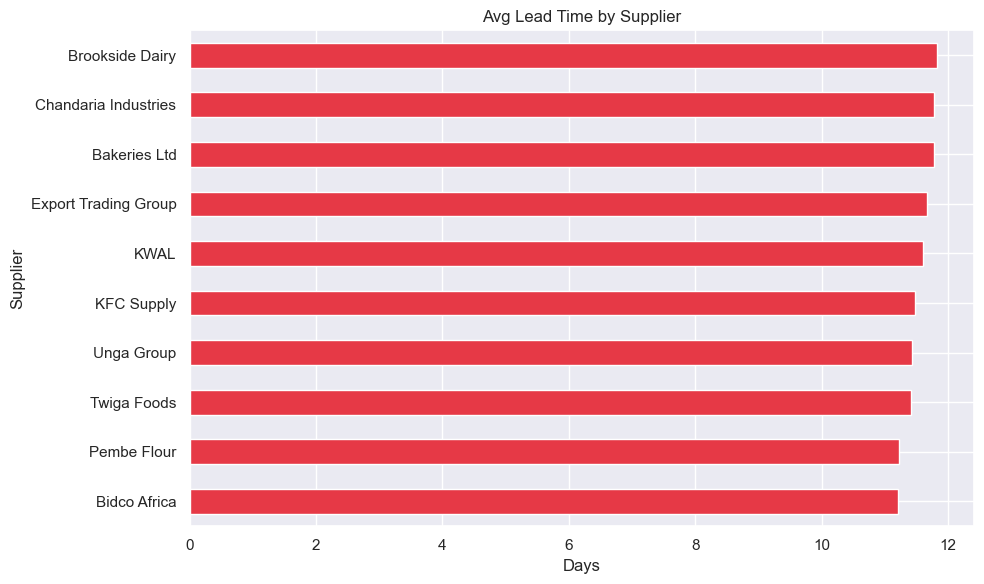

In [8]:
lead_time = df.groupby("Supplier")["Lead_Time_Days"].mean().sort_values(ascending=False)

display(lead_time.round(2).to_frame("Average Lead Time Days"))
lead_time.sort_values().plot(kind="barh", title="Avg Lead Time by Supplier", color=RISK_COLOR)
plt.xlabel("Days")
plt.ylabel("Supplier")
plt.tight_layout()
plt.show()

,Year,Month,Count,Period
0,2023,1,7,2023-01-01
1,2023,2,5,2023-02-01
2,2023,3,4,2023-03-01
3,2023,4,7,2023-04-01
4,2023,5,6,2023-05-01


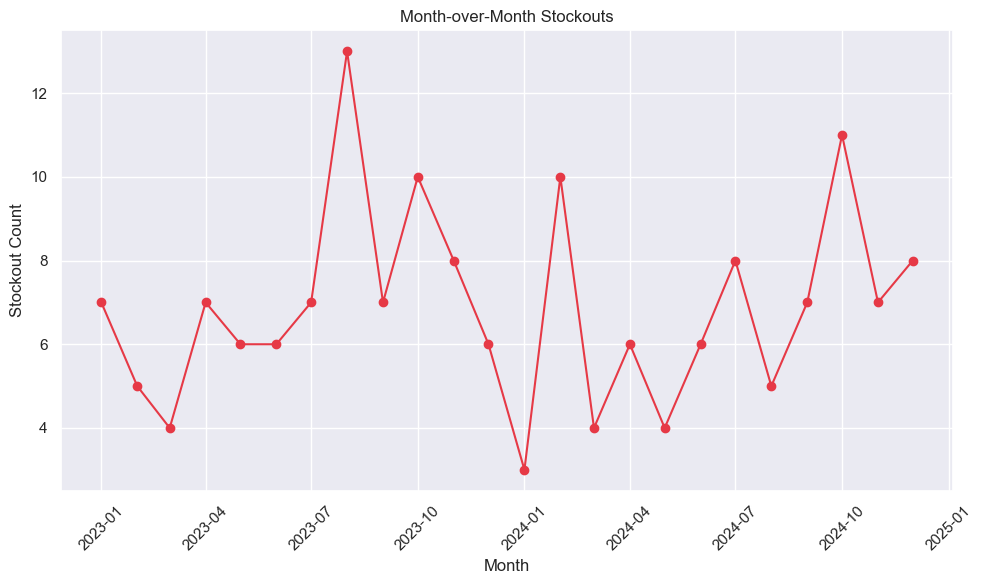

In [9]:
monthly_stockouts = (
    df[df["Stockout_Flag"] == "Yes"]
    .groupby(["Year", "Month"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Year", "Month"])
)
monthly_stockouts["Period"] = pd.to_datetime(
    monthly_stockouts["Year"].astype(str) + "-" + monthly_stockouts["Month"].astype(str) + "-01"
)

display(monthly_stockouts.head())
plt.plot(monthly_stockouts["Period"], monthly_stockouts["Count"], marker="o", color=RISK_COLOR)
plt.title("Month-over-Month Stockouts")
plt.xlabel("Month")
plt.ylabel("Stockout Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
region_stockout = (
    df.groupby("Region")["Stockout_Flag"]
    .apply(lambda x: (x == "Yes").sum())
    .sort_values(ascending=False)
)

display(region_stockout.to_frame("Stockout Count"))

,Stockout Count
Region,
Westlands,28
Thika Road,26
Mombasa Road,25
Ngong Road,23
Kiambu,22
Karen,21
Eastleigh,20


In [11]:
df["Fulfillment_Rate"] = df["Units_Received"] / df["Units_Ordered"]
fulfillment = df.groupby("Supplier")["Fulfillment_Rate"].mean().sort_values()

display((fulfillment * 100).round(2).to_frame("Fulfillment Rate %"))

,Fulfillment Rate %
Supplier,
Export Trading Group,92.37
Twiga Foods,92.44
Brookside Dairy,92.47
Bakeries Ltd,92.53
Pembe Flour,92.66
Unga Group,92.70
KFC Supply,92.73
Bidco Africa,92.74
Chandaria Industries,92.84


## Phase 4: Visualisation Dashboard

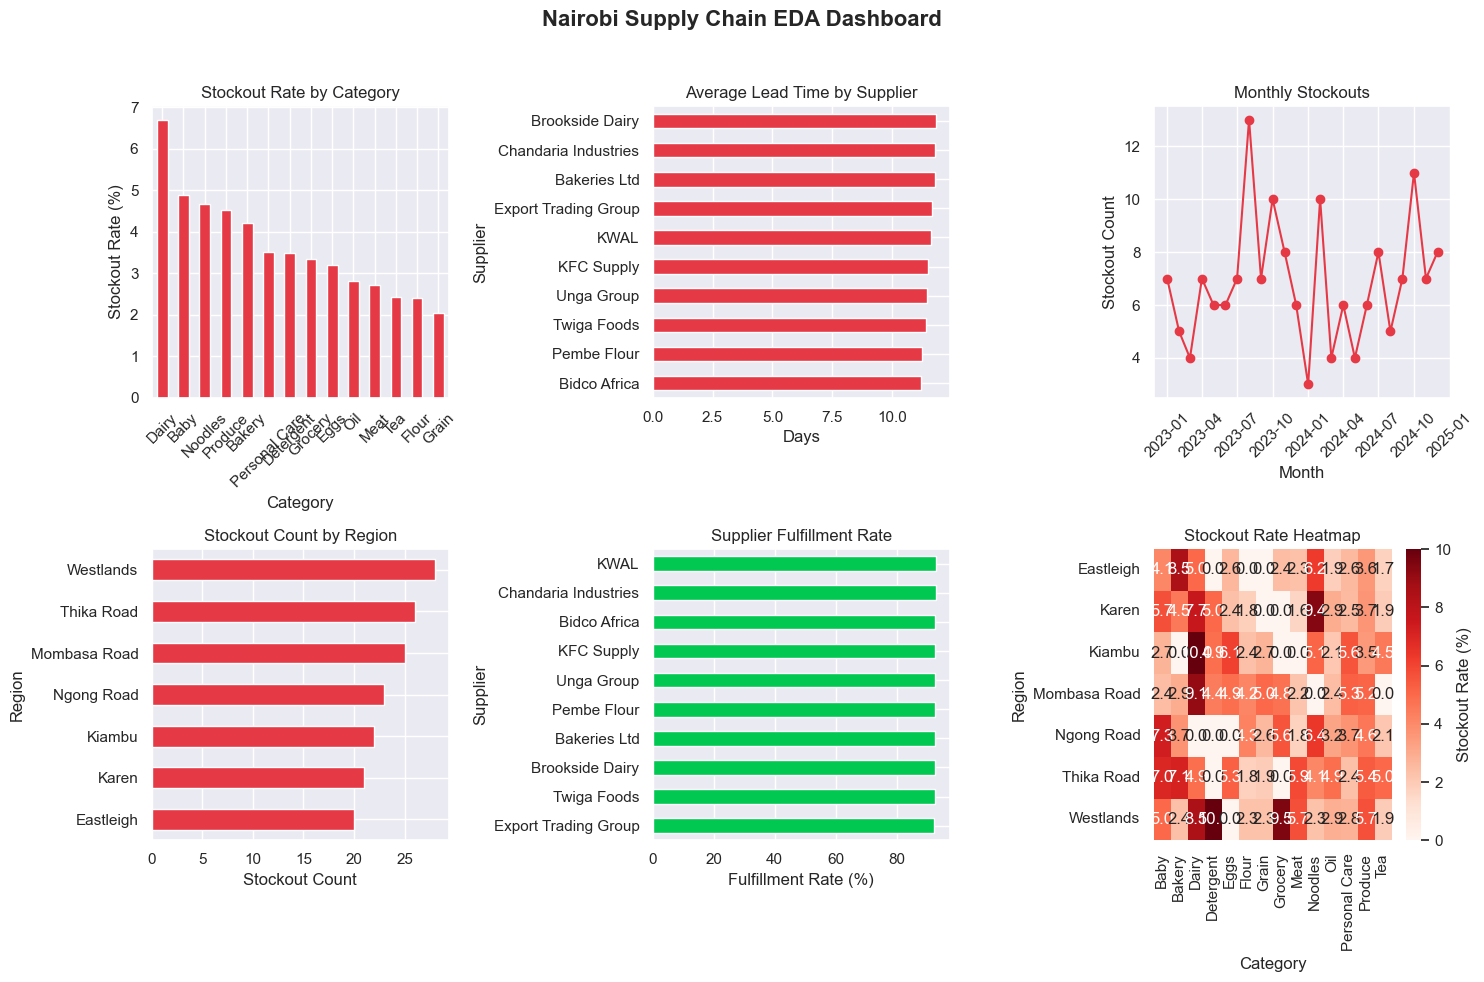

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Nairobi Supply Chain EDA Dashboard", fontsize=16, fontweight="bold")

(stockout_rate * 100).plot(kind="bar", ax=axes[0, 0], color=RISK_COLOR)
axes[0, 0].set_title("Stockout Rate by Category")
axes[0, 0].set_ylabel("Stockout Rate (%)")
axes[0, 0].set_xlabel("Category")
axes[0, 0].tick_params(axis="x", rotation=45)

lead_time.sort_values().plot(kind="barh", ax=axes[0, 1], color=RISK_COLOR)
axes[0, 1].set_title("Average Lead Time by Supplier")
axes[0, 1].set_xlabel("Days")
axes[0, 1].set_ylabel("Supplier")

axes[0, 2].plot(monthly_stockouts["Period"], monthly_stockouts["Count"], marker="o", color=RISK_COLOR)
axes[0, 2].set_title("Monthly Stockouts")
axes[0, 2].set_ylabel("Stockout Count")
axes[0, 2].set_xlabel("Month")
axes[0, 2].tick_params(axis="x", rotation=45)

region_stockout.sort_values().plot(kind="barh", ax=axes[1, 0], color=RISK_COLOR)
axes[1, 0].set_title("Stockout Count by Region")
axes[1, 0].set_xlabel("Stockout Count")
axes[1, 0].set_ylabel("Region")

(fulfillment * 100).plot(kind="barh", ax=axes[1, 1], color=POSITIVE_COLOR)
axes[1, 1].set_title("Supplier Fulfillment Rate")
axes[1, 1].set_xlabel("Fulfillment Rate (%)")
axes[1, 1].set_ylabel("Supplier")

heatmap_data = pd.crosstab(
    df["Region"],
    df["Category"],
    values=(df["Stockout_Flag"] == "Yes"),
    aggfunc="mean"
)
sns.heatmap(
    heatmap_data * 100,
    cmap="Reds",
    annot=True,
    fmt=".1f",
    ax=axes[1, 2],
    cbar_kws={"label": "Stockout Rate (%)"}
)
axes[1, 2].set_title("Stockout Rate Heatmap")
axes[1, 2].set_xlabel("Category")
axes[1, 2].set_ylabel("Region")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("week01_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 5: Data Quality Report Notes

In [13]:
top_issues = [
    f"Missing values: {int(missing.sum())} total missing cells.",
    f"Fulfillment anomalies: {len(anomalies)} rows where Units_Received exceeds Units_Ordered.",
    f"Duplicate TransactionIDs: {duplicate_count} duplicate transaction identifiers.",
]

top_insights = [
    f"{stockout_rate.index[0]} has the highest category stockout rate at {stockout_rate.iloc[0] * 100:.1f}%.",
    f"{lead_time.index[0]} has the longest average lead time at {lead_time.iloc[0]:.1f} days.",
    f"{region_stockout.index[0]} has the highest stockout count with {int(region_stockout.iloc[0])} stockout events.",
]

print("Top 3 data issues:")
for item in top_issues:
    print(f"- {item}")

print("\nTop 3 business insights:")
for item in top_insights:
    print(f"- {item}")

print("\nQuestion this data cannot answer:")
print("The data cannot explain the root cause of supplier delays or stockouts because it lacks supplier capacity, transport, payment, and warehouse process data.")

Top 3 data issues:
- Missing values: 0 total missing cells.
- Fulfillment anomalies: 0 rows where Units_Received exceeds Units_Ordered.
- Duplicate TransactionIDs: 0 duplicate transaction identifiers.

Top 3 business insights:
- Dairy has the highest category stockout rate at 6.7%.
- Brookside Dairy has the longest average lead time at 11.8 days.
- Westlands has the highest stockout count with 28 stockout events.

Question this data cannot answer:
The data cannot explain the root cause of supplier delays or stockouts because it lacks supplier capacity, transport, payment, and warehouse process data.
